In [1]:
# Path
import os, sys
os.chdir('/home/zwang34/IBL/iblfm_exp/IBL_foundation_model')
sys.path.append('./src')

In [2]:
from datasets import load_dataset, load_from_disk, concatenate_datasets, DatasetDict
from accelerate import Accelerator
from src.loader.make_loader import make_loader
from src.utils.dataset_utils import split_both_dataset, load_multi_session_dataset
from src.utils.utils import set_seed, move_batch_to_device, plot_gt_pred, metrics_list, plot_avg_rate_and_spike, \
    plot_rate_and_spike
from src.utils.config_utils import config_from_kwargs, update_config
from src.utils.hooks_utils import HookManager
from src.models.ndt1_v0 import NDT1  # only here is not compatible. Need to change this for non-regression.
from models.ndtgpt import NDTGPT
from src.models.stpatch import STPatch
from src.models.itransformer_multi import iTransformer  # use multi-version for now
from src.models.probe_decoders import ProbeDecoder
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import r2_score
from scipy.special import gammaln
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
from sklearn.cluster import SpectralClustering
import matplotlib.colors as colors
import os
import re
from src.trainer.make import make_trainer
from pathlib import Path
import wandb

NAME2MODEL = {"NDT1": NDT1, "STPatch": STPatch, "iTransformer": iTransformer, "NDT-GPT": NDTGPT}

/home/zwang34/miniconda3/envs/ibl-fm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_path = '/expanse/lustre/scratch/zwang34/temp_project/random_exp/alignment/train/model_NDT1_10ses_method_ssl_mask_neuron_ratio_0.3_ual_training_False_nonrand_False_PE_learnable_common/best'

In [4]:
kwargs = {
    "model": "include:src/configs/ndt1_v0/ndt1_v0.yaml"
}
config = config_from_kwargs(kwargs)
config = update_config("src/configs/ndt1_v0/trainer_ndt1_v0.yaml", config)
config = update_config("src/configs/ndt1_v0/probe.yaml", config)

# change the config model path
config['model']['encoder']['from_pt'] = model_path
config['model']['decoder']['from_pt'] = model_path

accelerator = Accelerator()

model_class = NAME2MODEL[config.model.model_class]
model = model_class(config.model, **config.method.model_kwargs)

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Created new subdict


In [5]:
model

NDT1(
  (encoder): NeuralEncoder(
    (masker): Masker()
    (norm_and_noise): NormAndNoise()
    (embedder): NeuralEmbeddingLayer(
      (embed_spikes): ModuleDict(
        (d0ea3148-948d-4817-94f8-dcaf2342bbbe): Linear(in_features=509, out_features=2048, bias=True)
        (3638d102-e8b6-4230-8742-e548cd87a949): Linear(in_features=522, out_features=2048, bias=True)
        (41872d7f-75cb-4445-bb1a-132b354c44f0): Linear(in_features=308, out_features=2048, bias=True)
        (db4df448-e449-4a6f-a0e7-288711e7a75a): Linear(in_features=465, out_features=2048, bias=True)
        (dac3a4c1-b666-4de0-87e8-8c514483cacf): Linear(in_features=692, out_features=2048, bias=True)
        (ecb5520d-1358-434c-95ec-93687ecd1396): Linear(in_features=988, out_features=2048, bias=True)
        (f312aaec-3b6f-44b3-86b4-3a0c119c0438): Linear(in_features=874, out_features=2048, bias=True)
        (4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b): Linear(in_features=869, out_features=2048, bias=True)
        (781b35fd-

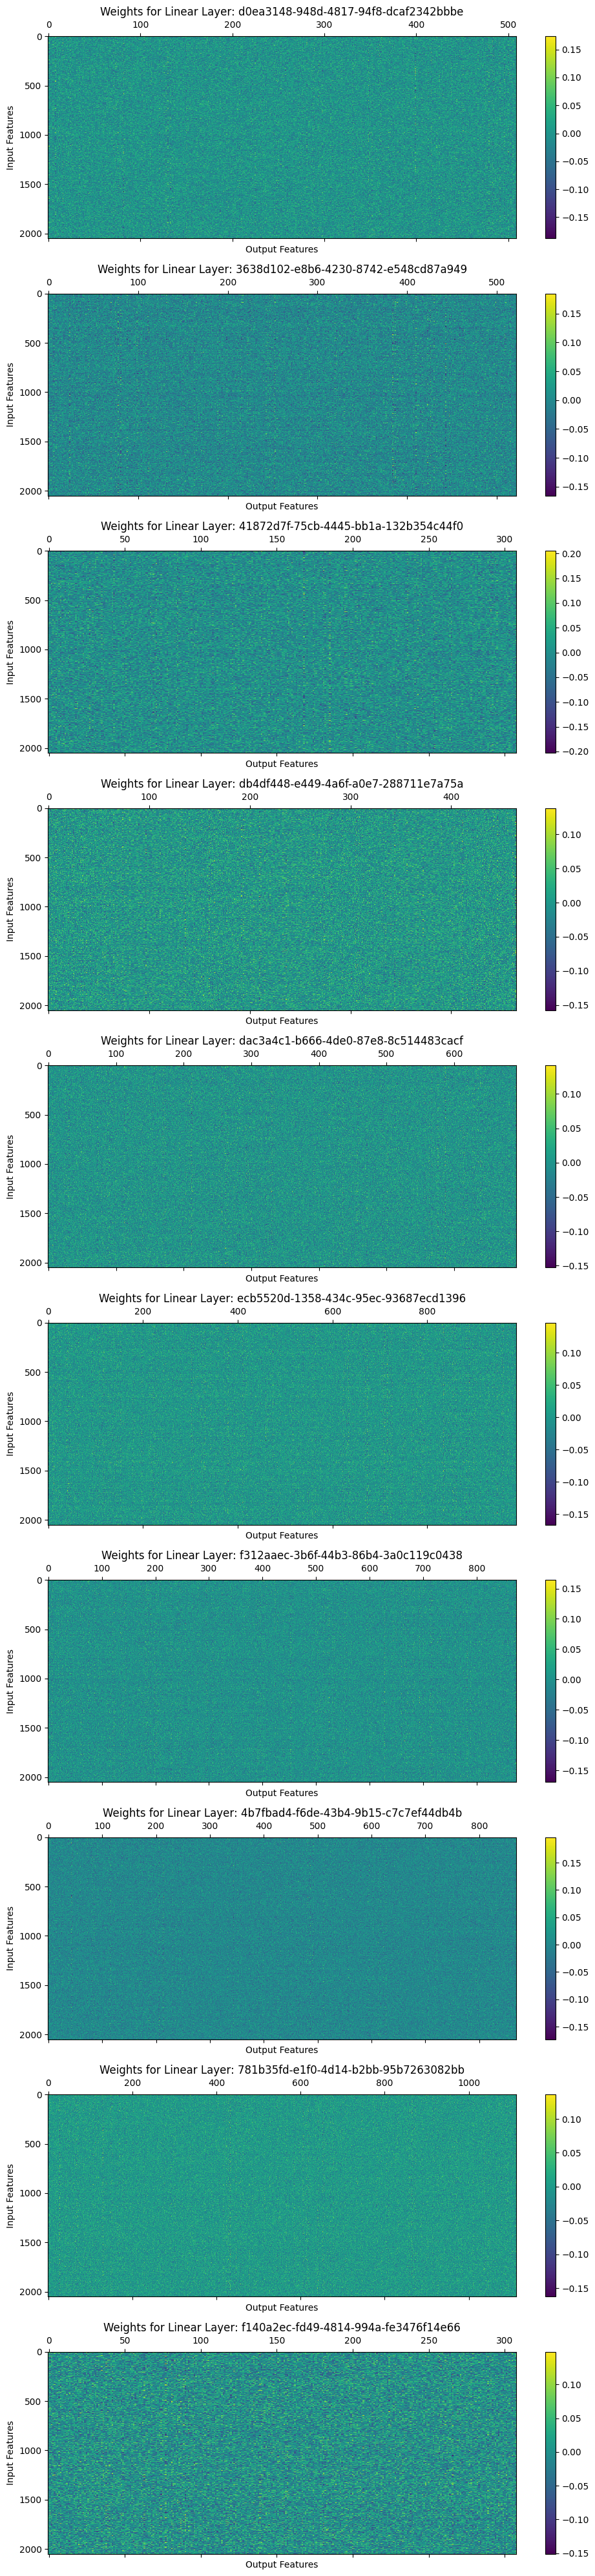

In [33]:
import torch
import matplotlib.pyplot as plt

# 定义用于可视化 embed_spikes 模块中 Linear 层权重的函数
def visualize_weights(embed_spikes_module):
    weights = {}
    # 获取 embed_spikes 中每个 Linear 层的权重
    for layer_name, layer in embed_spikes_module.items():
        weights[layer_name] = layer.weight.detach().cpu().numpy()  # 将权重转换为 numpy 数组以便绘图

    # 绘制每个 Linear 层的权重
    num_layers = len(weights)
    fig, axes = plt.subplots(num_layers, 1, figsize=(10, 4 * num_layers))
    
    if num_layers == 1:  # 如果只有一个层，将 axes 转为列表以保持索引一致性
        axes = [axes]
    
    for i, (layer_name, weight_matrix) in enumerate(weights.items()):
        ax = axes[i]
        cax = ax.matshow(weight_matrix, aspect='auto')
        fig.colorbar(cax, ax=ax)
        ax.set_title(f"Weights for Linear Layer: {layer_name}")
        ax.set_xlabel("Output Features")
        ax.set_ylabel("Input Features")
    
    plt.tight_layout()
    plt.show()
    return weights

# 在本地环境中调用时，替换 model.encoder.embedder.embed_spikes 为实际的 embed_spikes 路径
weights = visualize_weights(model.encoder.embedder.embed_spikes)
# weights = visualize_weights(model.decoder)


In [36]:
mat_list = []
for cur_mat in weights.values():
    mat_list.append(cur_mat.T)
mat_all = np.concatenate(mat_list, axis=0)
mat_all.shape

(6648, 2048)

In [37]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

def compute_similarity_matrix(matrix, metric='cosine'):
    """
    Compute m x m similarity matrix for a given m x n matrix.
    
    Parameters:
    - matrix: np.ndarray, input matrix with shape (m, n)
    - metric: str, 'cosine' for cosine similarity, 'euclidean' for euclidean distance

    Returns:
    - similarity_matrix: np.ndarray, m x m similarity matrix
    """
    if metric == 'cosine':
        similarity_matrix = cosine_similarity(matrix)
    elif metric == 'euclidean':
        similarity_matrix = -euclidean_distances(matrix)
    else:
        raise ValueError("Unsupported metric. Choose 'cosine' or 'euclidean'.")
    
    return similarity_matrix

(509, 509)


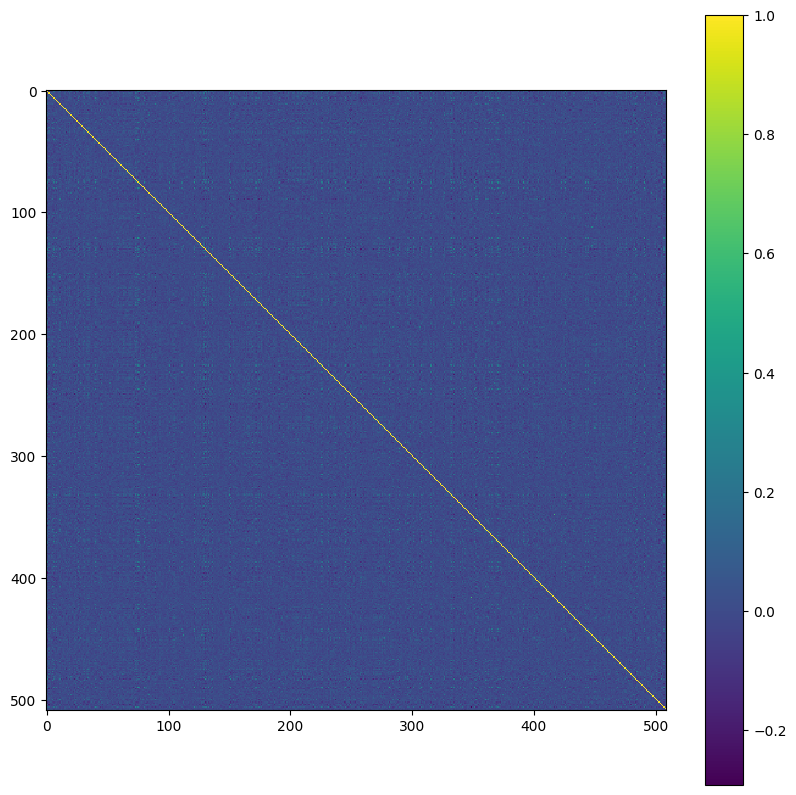

In [39]:
rsm = compute_similarity_matrix(mat_list[0], metric='cosine')
plt.figure(figsize=(10, 10))
plt.imshow(rsm, interpolation='none')
plt.colorbar()
print(rsm.shape)

## UMAP & t-SNE

/home/zwang34/miniconda3/envs/ibl-fm/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/scratch/zwang34/job_34959901/ipykernel_1092180/93965115.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embedding[:, 0], embedding[:, 1], s=5, cmap='viridis')


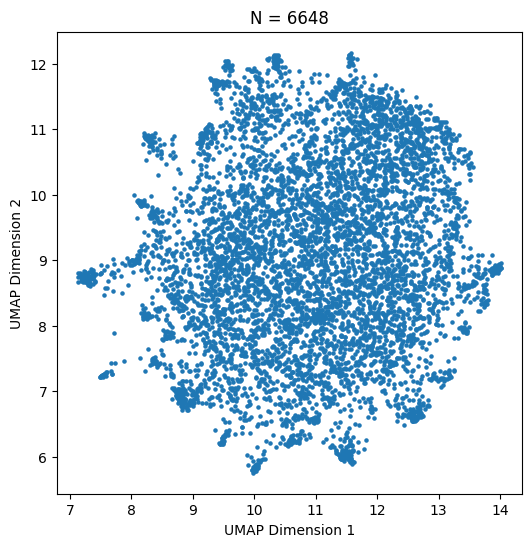

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import umap

def visualize_umap(matrix, n_neighbors=15, min_dist=0.1, metric='euclidean', random_seed=42):
    """
    Perform UMAP on an m x n matrix and visualize the result in 2D.
    
    Parameters:
    - matrix: np.ndarray, input matrix with shape (m, n)
    - n_neighbors: int, UMAP parameter controlling local neighborhood size
    - min_dist: float, UMAP parameter controlling the minimum distance between points
    - metric: str, distance metric to use for UMAP
    """
    # Initialize UMAP model
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, n_components=2, random_state=random_seed)
    # Transform the data
    embedding = reducer.fit_transform(matrix)
    
    # Plot the 2D embedding
    plt.figure(figsize=(6, 6))
    plt.scatter(embedding[:, 0], embedding[:, 1], s=5, cmap='viridis')
    plt.title(f"N = {embedding.shape[0]}")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    # plt.colorbar(label='Sample Index')
    plt.show()

    return embedding

embedding_umap = visualize_umap(mat_all, metric='cosine', n_neighbors=50, min_dist=0.1, random_seed=32)


/scratch/zwang34/job_34959901/ipykernel_1092180/1900188299.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embedding_tsne[:, 0], embedding_tsne[:, 1], s=5, cmap='viridis')


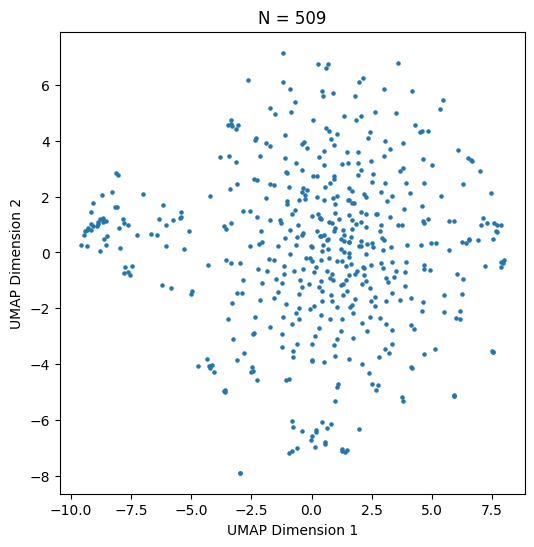

In [73]:
import numpy as np
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=32)
embedding_tsne = tsne.fit_transform(mat_list[0])

# Plot the 2D embedding
plt.figure(figsize=(6, 6))
plt.scatter(embedding_tsne[:, 0], embedding_tsne[:, 1], s=5, cmap='viridis')
plt.title(f"N = {embedding_tsne.shape[0]}")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
# plt.colorbar(label='Sample Index')
plt.show()

### Correlations with Brain Regions

In [74]:
from datasets import load_dataset

def get_region_dict(model_module):
    region_dict = {}
    for layer_name, layer in model_module.items():
        dataset = load_dataset(f'ibl-foundation-model/{layer_name}_aligned', cache_dir='/expanse/lustre/scratch/zwang34/temp_project/iTransformer/checkpoints/datasets_cache')
        region_dict[layer_name] = [x for _, x in sorted(zip(dataset['train'][0]['cluster_uuids'], dataset['train'][0]['cluster_regions']))]
    return region_dict

region_dict = get_region_dict(model.decoder)

In [79]:
region_list = []
for neuron_region in region_dict.values():
    region_list.append(neuron_region)

region_list_all = [r for sub_list in region_list for r in sub_list]
print(len(region_list_all))

6648


(6648, 2) 6648


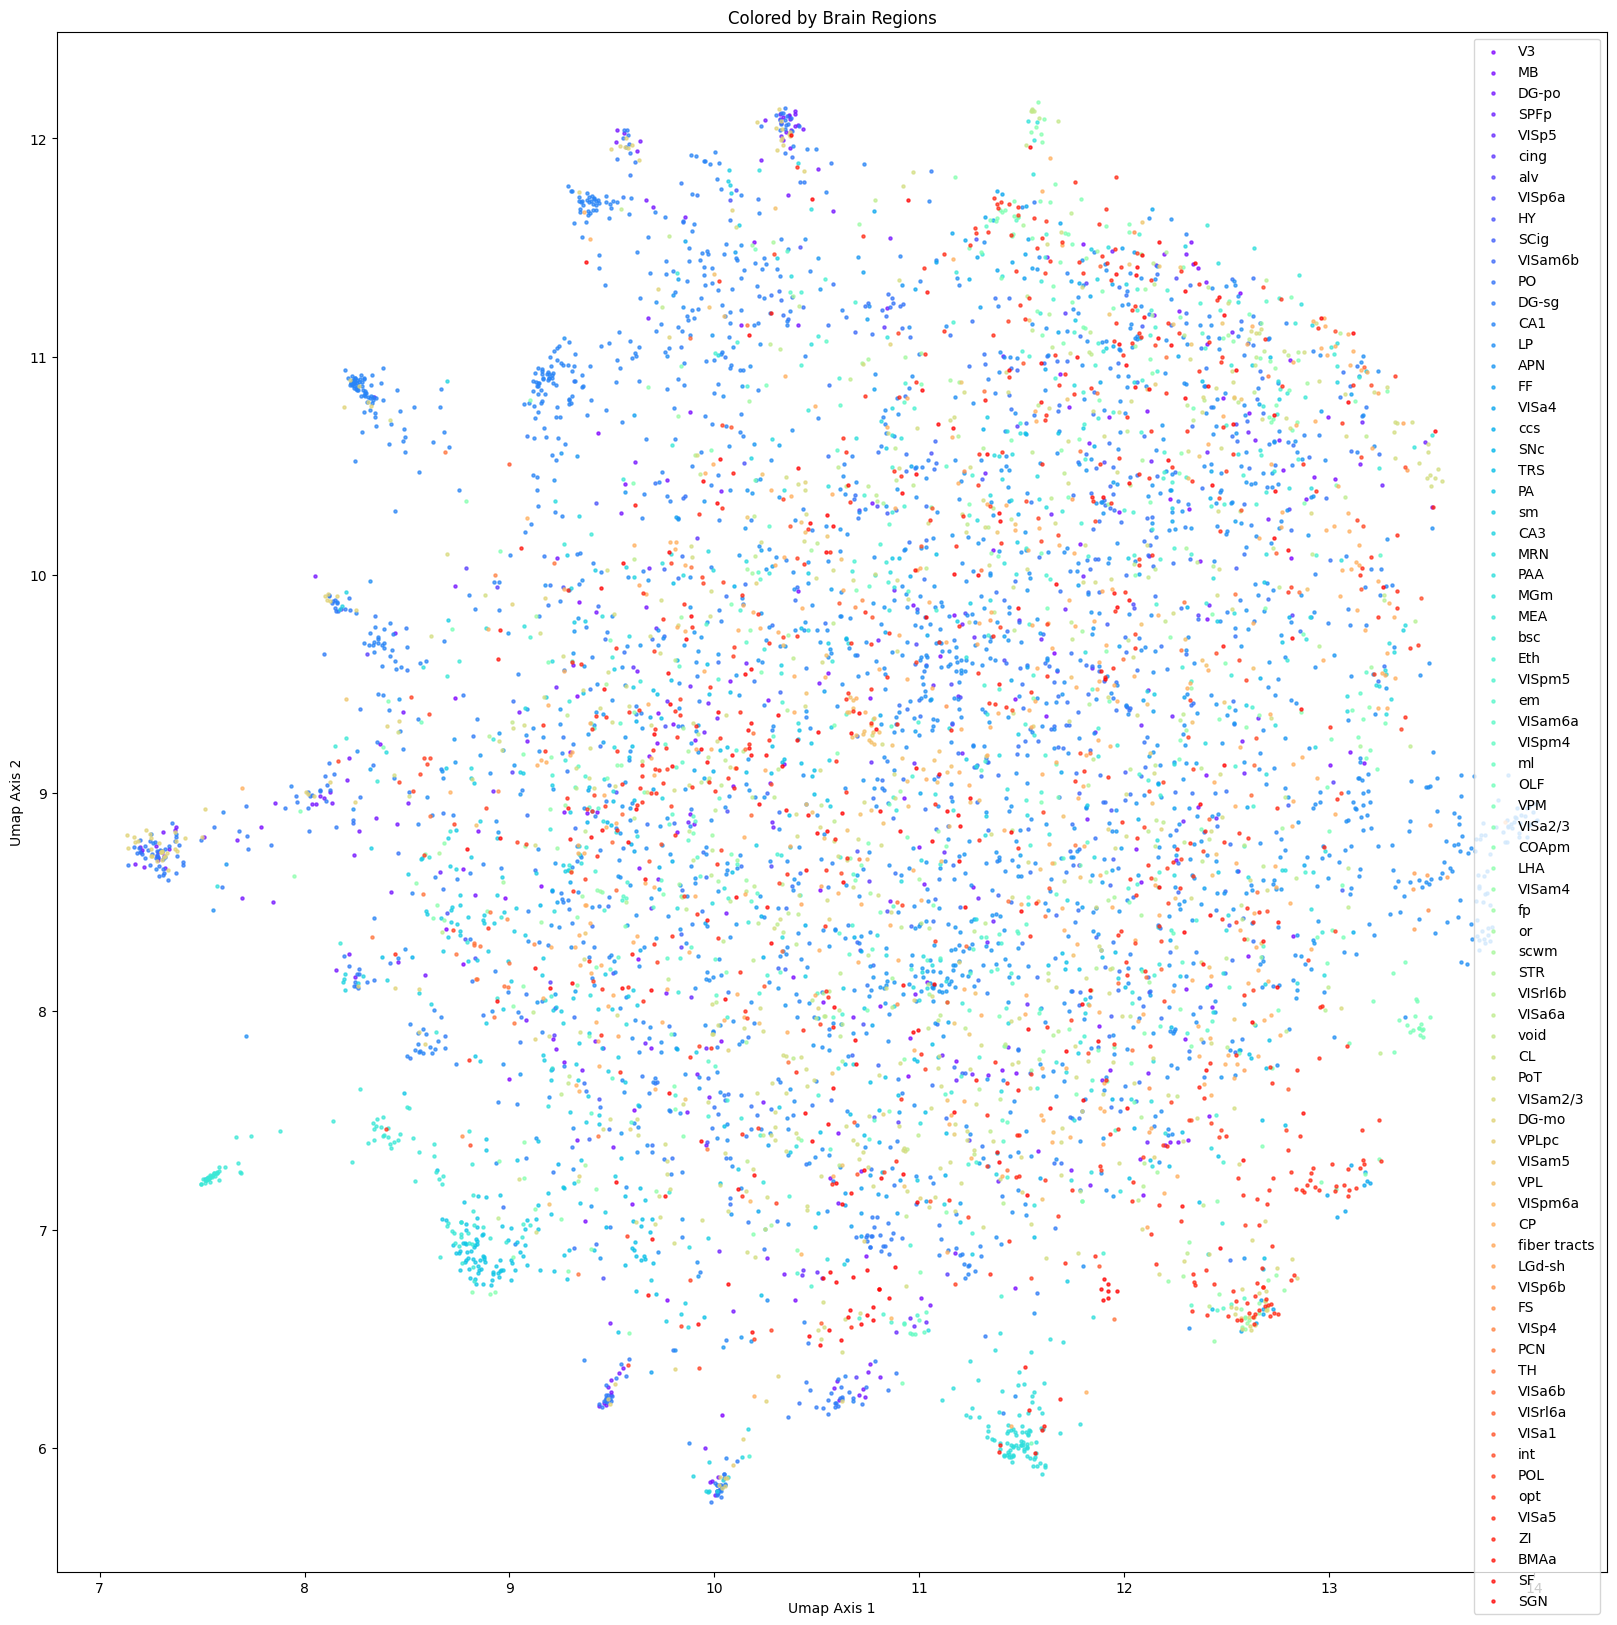

In [90]:
def plot_scatter_with_labels(matrix, labels):
    """
    绘制带有标签的散点图，相同标签的点具有相同的颜色。

    参数:
    - matrix: m x 2 的 NumPy 数组或列表，表示二维坐标。
    - labels: 长度为 m 的字符串列表，表示每个点的类别标签。

    返回:
    - None，直接显示图像。
    """
    print(matrix.shape, len(labels))
    matrix = np.array(matrix)
    unique_labels = list(set(labels))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
    
    plt.figure(figsize=(20, 20))
    for i, label in enumerate(unique_labels):
        indices = [j for j, x in enumerate(labels) if x == label]
        plt.scatter(matrix[indices, 0], matrix[indices, 1], label=label, color=colors[i], alpha=0.7, s=5)
    
    plt.xlabel('Umap Axis 1')
    plt.ylabel('Umap Axis 2')
    plt.title('Colored by Brain Regions')
    plt.legend()
    plt.savefig('Stitcher.png')
    plt.show()

plot_scatter_with_labels(embedding_umap, region_list_all)